# DSA210 Term Project - Exploratory Data Analysis

## Alcohol Consumption and Traffic Accidents in Turkey

This notebook contains the data-loading and exploratory data analysis (EDA) phase
of the project. Hypothesis testing is in `DSA210_Hypothesis_Testing.ipynb`.

**Geographic unit:** This analysis uses the **IBBS-2** (NUTS-2) regional
classification (26 sub-regions) for the alcohol-consumption variable. This is
finer-grained than IBBS-1 (12 regions) and produces 26 unique alcohol rates
instead of 12.

**Author:** Mustafa Arda Terzi
**Course:** DSA210 - Introduction to Data Science


## 0. Imports & Settings

In [8]:
# Standard library
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical testing
from scipy import stats

# Display helpers
from IPython.display import display
def display_full(d, max_rows=200):
    with pd.option_context('display.max_rows', max_rows,
                           'display.max_columns', None,
                           'display.width', None):
        display(d)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

# Shared colour palette
ACCENT = '#E63946'
BLUE   = '#457B9D'
GREEN  = '#2A9D8F'

# Reproducibility
np.random.seed(42)

# External data files (place these alongside the notebook)
TRAFFIC_XLSX = 'traffic_accidents.xlsx'
POP_XLS      = 'Population of provinces by years.xls'
IBBS2_XLSX   = 'province_alcohol_ibbs2.csv.xlsx'


## 1. Data Loading

All three datasets are loaded from external Excel files. **Nothing is hardcoded.**

| Dataset | Source file | Source notes |
| --- | --- | --- |
| 2025 traffic accidents (per province) | `traffic_accidents.xlsx`, sheet `2025` | EGM bulletins (Aralık 2025 cumulative) |
| 2026 Q1 traffic accidents (per province) | `traffic_accidents.xlsx`, sheet `2026Q1` | EGM Q1 2026 bulletin |
| Province population (2025 projection) | `Population_of_provinces_by_years.xls` | TurkStat Population Projections |
| Alcohol rate + IBBS-2 mapping | `province_alcohol_ibbs2_csv.xlsx` | Pre-computed from TUIK 2022 Health Survey microdata, weighted by FERTFAKTOR, restricted to current drinkers (drank in last 12 months) |

**Why IBBS-2 instead of IBBS-1?** Turkey's 81 provinces map to 12 NUTS-1 (IBBS-1)
regions or 26 NUTS-2 (IBBS-2) sub-regions. Using IBBS-2 gives more variation in
the alcohol feature (26 unique values vs 12) and more statistical power for the
regional-level test (H3 below).


### 1.1 Traffic Accidents (2025 + 2026 Q1)

In [5]:
df_2025   = pd.read_excel(TRAFFIC_XLSX, sheet_name='2025')
df_2026q1 = pd.read_excel(TRAFFIC_XLSX, sheet_name='2026Q1')

for d in (df_2025, df_2026q1):
    d.index = range(1, len(d) + 1)
    d.index.name = 'No'

print(f'2025 dataset    : {len(df_2025)} provinces, '
      f'total injury/fatal accidents {df_2025["injury_fatal_accidents"].sum():,}, '
      f'fatalities {df_2025["fatalities"].sum():,}')
print(f'2026 Q1 dataset : {len(df_2026q1)} provinces, '
      f'total injury/fatal accidents {df_2026q1["injury_fatal_accidents"].sum():,}, '
      f'fatalities {df_2026q1["fatalities"].sum():,}')

print('\n2025 (full year):')
display_full(df_2025)
print('\n2026 Q1 (Jan-Mar):')
display_full(df_2026q1)


2025 dataset    : 81 provinces, total injury/fatal accidents 288,253, fatalities 2,541
2026 Q1 dataset : 81 provinces, total injury/fatal accidents 55,582, fatalities 420

2025 (full year):


,province,injury_fatal_accidents,material_damage_accidents,fatalities,injured
No,,,,,
1,Adana,6765,6757,71,9372
2,Adiyaman,2234,1776,23,3400
3,Afyonkarahisar,2871,3185,24,4863
4,Agri,947,1123,7,1739
5,Amasya,1699,1475,20,2722
6,Ankara,17540,78863,159,23717
7,Antalya,14241,12376,98,19040
8,Artvin,340,489,7,518
9,Aydin,6035,4016,59,8211



2026 Q1 (Jan-Mar):


,province,injury_fatal_accidents,material_damage_accidents,fatalities,injured
No,,,,,
1,Adana,1440,2003,12,1967
2,Adiyaman,321,471,4,525
3,Afyonkarahisar,520,799,1,874
4,Agri,170,355,1,316
5,Amasya,295,385,3,459
6,Ankara,3706,20708,29,5063
7,Antalya,2691,2838,18,3584
8,Artvin,51,120,3,75
9,Aydin,1178,1009,6,1609


### 1.2 Province Population - 2025

The TurkStat Population Projections file has a metadata-heavy header. We skip
the first two rows so that the third row becomes our column headers, then drop
the total/footer rows so we end up with exactly 81 provinces.


In [6]:
def turkish_to_ascii(s):
    """Convert Turkish-specific characters to ASCII so province names match
    across files (e.g. 'Adıyaman' -> 'Adiyaman')."""
    if not isinstance(s, str):
        return s
    return s.translate(str.maketrans({
        'İ':'I','ı':'i','Ş':'S','ş':'s','Ç':'C','ç':'c',
        'Ğ':'G','ğ':'g','Ü':'U','ü':'u','Ö':'O','ö':'o',
    }))

raw_pop = pd.read_excel(POP_XLS, header=2)
non_province = (r'Total|Toplam|TUIK|TurkStat|Address|Population|'
                r'Adrese|Nüfus|Figures|Tablo|Results')
mask = (raw_pop['İl-Province'].notna() &
        ~raw_pop['İl-Province'].astype(str).str.contains(non_province,
                                                          case=False, regex=True))
raw_pop = raw_pop[mask].copy()
assert len(raw_pop) == 81, f'Expected 81 provinces, got {len(raw_pop)}'

df_pop = pd.DataFrame({
    'province'       : raw_pop['İl-Province'].apply(turkish_to_ascii).values,
    'population_2025': raw_pop[2025].astype(int).values,
})
df_pop.index = range(1, len(df_pop) + 1)
df_pop.index.name = 'No'

print(f'Total Turkey population (81 provinces, 2025 projection): '
      f'{df_pop["population_2025"].sum():,}')
display_full(df_pop.sort_values('population_2025', ascending=False))


Total Turkey population (81 provinces, 2025 projection): 86,239,196


,province,population_2025
No,,
34,Istanbul,15817365
6,Ankara,5886877
35,Izmir,4524368
16,Bursa,3280388
7,Antalya,2771976
42,Konya,2341719
1,Adana,2266381
63,Sanliurfa,2257242
27,Gaziantep,2196824


### 1.3 Alcohol Consumption + Province → IBBS-2 Mapping

This single Excel file contains both:
- the structural province → IBBS-2 sub-region mapping
  (`nuts2_label`, `parent_ibbs1_tr`, `ibbs2_sozde_code`)
- the survey-weighted alcohol consumption rate per IBBS-2 sub-region
  (`alcohol_rate_pct_ibbs2`)

The rates were computed from TUIK's 2022 Türkiye Sağlık Araştırması microdata
(~30 000 individual respondents, aged 15+) using survey weights (FERTFAKTOR).
A "current drinker" is defined as having drunk alcohol in the last 12 months.


In [9]:
df_ibbs2 = pd.read_excel(IBBS2_XLSX)
print(f'IBBS-2 file: {df_ibbs2.shape}')
print(f'Columns: {list(df_ibbs2.columns)}')

# Standardise column name for downstream code
df_ibbs2 = df_ibbs2.rename(columns={'alcohol_rate_pct_ibbs2': 'alcohol_rate_pct'})

assert len(df_ibbs2) == 81, f'Expected 81 provinces, got {len(df_ibbs2)}'
assert df_ibbs2['nuts2_label'].nunique() == 26, \
    f"Expected 26 IBBS-2 sub-regions, got {df_ibbs2['nuts2_label'].nunique()}"

print(f'\nDistinct IBBS-1 parent regions : {df_ibbs2["parent_ibbs1_tr"].nunique()}')
print(f'Distinct IBBS-2 sub-regions    : {df_ibbs2["nuts2_label"].nunique()}')
print(f'Distinct alcohol rate values   : {df_ibbs2["alcohol_rate_pct"].nunique()}')
print(f'Range of alcohol rates         : '
      f'{df_ibbs2["alcohol_rate_pct"].min():.1f}% - '
      f'{df_ibbs2["alcohol_rate_pct"].max():.1f}%')

display_full(df_ibbs2)


IBBS-2 file: (81, 6)
Columns: ['province', 'nuts2_label', 'parent_ibbs1_tr', 'ibbs2_sozde_code', 'alcohol_rate_pct_ibbs2', 'n_survey_respondents']

Distinct IBBS-1 parent regions : 12
Distinct IBBS-2 sub-regions    : 26
Distinct alcohol rate values   : 26
Range of alcohol rates         : 0.1% - 26.8%


,province,nuts2_label,parent_ibbs1_tr,ibbs2_sozde_code,alcohol_rate_pct,n_survey_respondents
0,Istanbul,TR10,TR1,16,16.90,4351
1,Tekirdag,TR21,TR2,25,26.76,459
2,Edirne,TR21,TR2,25,26.76,459
3,Kirklareli,TR21,TR2,25,26.76,459
4,Balikesir,TR22,TR2,12,18.00,537
5,Canakkale,TR22,TR2,12,18.00,537
6,Izmir,TR31,TR3,23,23.10,1298
7,Aydin,TR32,TR3,8,18.88,993
8,Denizli,TR32,TR3,8,18.88,993
9,Mugla,TR32,TR3,8,18.88,993


## 2. Data Merging & Feature Engineering

In [10]:
df = (df_2025
      .merge(df_2026q1, on='province', suffixes=('_2025', '_2026q1'))
      .merge(df_pop,   on='province')
      .merge(df_ibbs2[['province','nuts2_label','parent_ibbs1_tr','alcohol_rate_pct']],
             on='province'))

assert len(df) == 81, f'Merged frame has {len(df)} provinces, expected 81'
assert df['alcohol_rate_pct'].notna().all(), 'Some provinces missing alcohol rate'

# Project 2026 Q1 to a full-year estimate (multiply by 4)
df['injury_fatal_accidents_2026_proj'] = df['injury_fatal_accidents_2026q1'] * 4
df['fatalities_2026_proj']             = df['fatalities_2026q1']             * 4
df['injured_2026_proj']                = df['injured_2026q1']                * 4

# Per-100 000 population rates (the main analytical variables)
df['acc_per_100k']      = df['injury_fatal_accidents_2025'] / df['population_2025'] * 100_000
df['fatality_per_100k'] = df['fatalities_2025']             / df['population_2025'] * 100_000
df['injured_per_100k']  = df['injured_2025']                / df['population_2025'] * 100_000
df['acc_per_100k_2026q1_proj'] = df['injury_fatal_accidents_2026_proj'] / df['population_2025'] * 100_000

df.index = range(1, len(df) + 1)
df.index.name = 'No'

print(f'Final merged dataset: {df.shape}')
display_full(df)


Final merged dataset: (81, 20)


,province,injury_fatal_accidents_2025,material_damage_accidents_2025,fatalities_2025,injured_2025,injury_fatal_accidents_2026q1,material_damage_accidents_2026q1,fatalities_2026q1,injured_2026q1,population_2025,nuts2_label,parent_ibbs1_tr,alcohol_rate_pct,injury_fatal_accidents_2026_proj,fatalities_2026_proj,injured_2026_proj,acc_per_100k,fatality_per_100k,injured_per_100k,acc_per_100k_2026q1_proj
No,,,,,,,,,,,,,,,,,,,,
1,Adana,6765,6757,71,9372,1440,2003,12,1967,2266381,TR62,TR6,13.28,5760,48,7868,298.493501,3.132748,413.522704,254.149677
2,Adiyaman,2234,1776,23,3400,321,471,4,525,607593,TRC1,TRC,3.12,1284,16,2100,367.680339,3.785429,559.585117,211.325674
3,Afyonkarahisar,2871,3185,24,4863,520,799,1,874,753047,TR33,TR3,9.65,2080,4,3496,381.251104,3.187052,645.776426,276.211179
4,Agri,947,1123,7,1739,170,355,1,316,493126,TRA2,TRA,1.61,680,4,1264,192.040168,1.419515,352.648208,137.895791
5,Amasya,1699,1475,20,2722,295,385,3,459,340490,TR83,TR8,6.94,1180,12,1836,498.986754,5.873888,799.436107,346.559370
6,Ankara,17540,78863,159,23717,3706,20708,29,5063,5886877,TR51,TR5,14.68,14824,116,20252,297.950849,2.700923,402.879150,251.814332
7,Antalya,14241,12376,98,19040,2691,2838,18,3584,2771976,TR61,TR6,22.12,10764,72,14336,513.749037,3.535384,686.874634,388.315050
8,Artvin,340,489,7,518,51,120,3,75,171614,TR90,TR9,6.31,204,12,300,198.119035,4.078921,301.840176,118.871421
9,Aydin,6035,4016,59,8211,1178,1009,6,1609,1179886,TR32,TR3,18.88,4712,24,6436,511.490093,5.000483,695.914690,399.360616


### 2.1 Sub-Regional Aggregates (n=26 IBBS-2 sub-regions)

For tests that need **independent observations** of alcohol consumption, we
aggregate the 81 provinces into 26 IBBS-2 sub-regions. Each sub-region has its
own alcohol rate; provinces within a sub-region all share the same rate.


In [11]:
df_subregion = df.groupby('nuts2_label').agg(
    parent_ibbs1_tr             = ('parent_ibbs1_tr',           'first'),
    n_provinces                 = ('province',                  'count'),
    total_population            = ('population_2025',           'sum'),
    injury_fatal_accidents_2025 = ('injury_fatal_accidents_2025','sum'),
    fatalities_2025             = ('fatalities_2025',           'sum'),
    injured_2025                = ('injured_2025',              'sum'),
    alcohol_rate_pct            = ('alcohol_rate_pct',          'first'),
).reset_index()

df_subregion['acc_per_100k']      = df_subregion['injury_fatal_accidents_2025'] / df_subregion['total_population'] * 100_000
df_subregion['fatality_per_100k'] = df_subregion['fatalities_2025']             / df_subregion['total_population'] * 100_000
df_subregion['injured_per_100k']  = df_subregion['injured_2025']                / df_subregion['total_population'] * 100_000

df_subregion.index = range(1, len(df_subregion) + 1)
df_subregion.index.name = 'No'

print(f'Sub-region aggregates: {df_subregion.shape} (should be 26 rows)')
display_full(df_subregion[['nuts2_label','parent_ibbs1_tr','n_provinces','total_population',
                            'acc_per_100k','fatality_per_100k','alcohol_rate_pct']])


Sub-region aggregates: (26, 11) (should be 26 rows)


,nuts2_label,parent_ibbs1_tr,n_provinces,total_population,acc_per_100k,fatality_per_100k,alcohol_rate_pct
No,,,,,,,
1,TR10,TR1,1,15817365,248.163964,0.847170,16.90
2,TR21,TR2,3,2022306,317.014339,3.065807,26.76
3,TR22,TR2,2,1863858,441.020722,6.116346,18.00
4,TR31,TR3,1,4524368,342.788208,2.696509,23.10
5,TR32,TR3,3,3341540,534.154911,5.356812,18.88
6,TR33,TR3,4,3192521,410.052119,4.823774,9.65
7,TR41,TR4,3,4445902,325.985593,2.024336,14.08
8,TR42,TR4,5,4350193,375.776431,2.482648,2.30
9,TR51,TR5,1,5886877,297.950849,2.700923,14.68


## 3. Exploratory Data Analysis

### 3.1 Descriptive Statistics

In [12]:
key_cols = ['injury_fatal_accidents_2025', 'fatalities_2025', 'injured_2025',
            'population_2025', 'acc_per_100k', 'fatality_per_100k']
display_full(df[key_cols].describe().round(1))


,injury_fatal_accidents_2025,fatalities_2025,injured_2025,population_2025,acc_per_100k,fatality_per_100k
count,81.0,81.0,81.0,81.0,81.0,81.0
mean,3558.7,31.4,5029.0,1064681.4,350.1,3.7
std,5280.1,32.1,6642.4,1924108.7,108.2,1.8
min,169.0,1.0,296.0,82593.0,108.7,0.6
25%,1026.0,9.0,1650.0,316266.0,282.1,2.4
50%,1676.0,21.0,2719.0,560036.0,346.5,3.5
75%,4373.0,39.0,6122.0,1122636.0,432.7,4.9
max,39253.0,159.0,47861.0,15817365.0,657.7,9.3


### 3.2 Distribution of Accident Rates Across Provinces

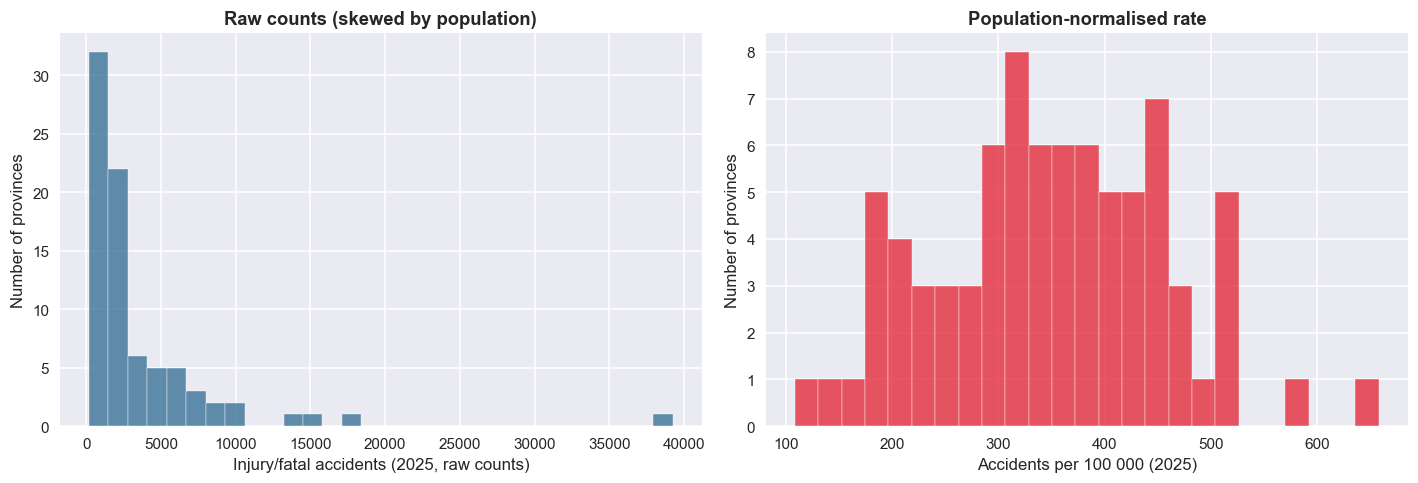

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df['injury_fatal_accidents_2025'], bins=30, color=BLUE,
             edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Injury/fatal accidents (2025, raw counts)')
axes[0].set_ylabel('Number of provinces')
axes[0].set_title('Raw counts (skewed by population)', fontweight='bold')

axes[1].hist(df['acc_per_100k'], bins=25, color=ACCENT, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Accidents per 100 000 (2025)')
axes[1].set_ylabel('Number of provinces')
axes[1].set_title('Population-normalised rate', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_accident_distribution.png', bbox_inches='tight')
plt.show()


### 3.3 Top and Bottom 10 Provinces by Accident Rate

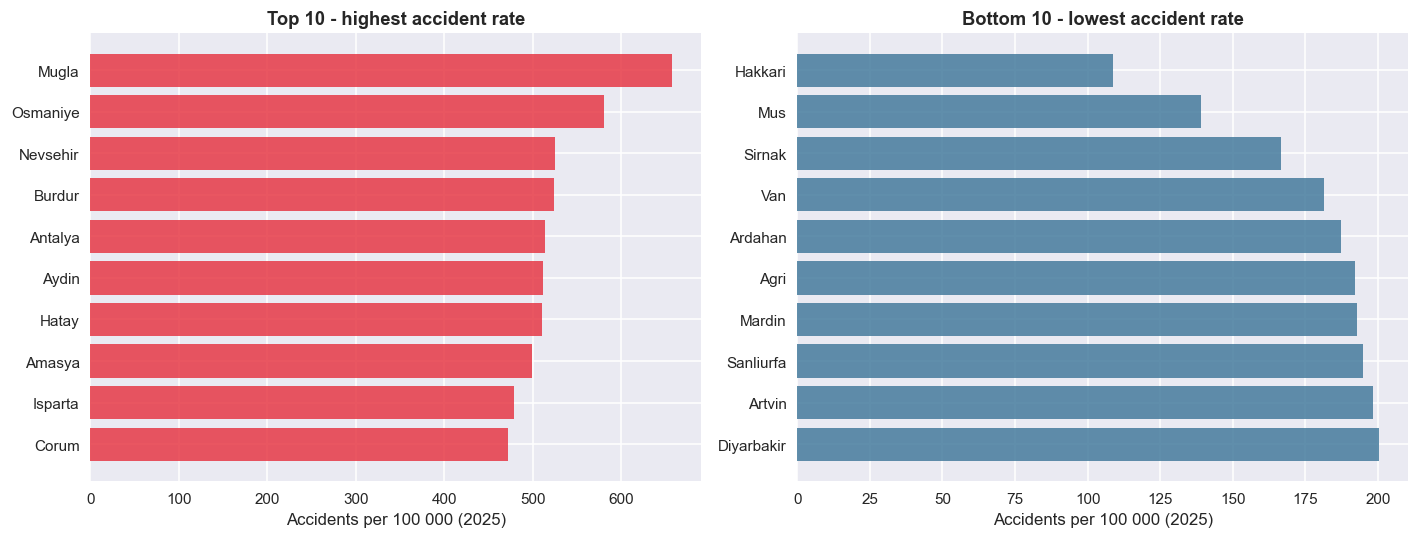

In [14]:
top10 = df.nlargest(10, 'acc_per_100k')
bot10 = df.nsmallest(10, 'acc_per_100k')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(top10['province'][::-1], top10['acc_per_100k'][::-1], color=ACCENT, alpha=0.85)
axes[0].set_xlabel('Accidents per 100 000 (2025)')
axes[0].set_title('Top 10 - highest accident rate', fontweight='bold')

axes[1].barh(bot10['province'][::-1], bot10['acc_per_100k'][::-1], color=BLUE, alpha=0.85)
axes[1].set_xlabel('Accidents per 100 000 (2025)')
axes[1].set_title('Bottom 10 - lowest accident rate', fontweight='bold')

plt.tight_layout()
plt.savefig('fig2_top_bottom10.png', bbox_inches='tight')
plt.show()


### 3.4 Big 3 Cities - Istanbul, Ankara, Izmir

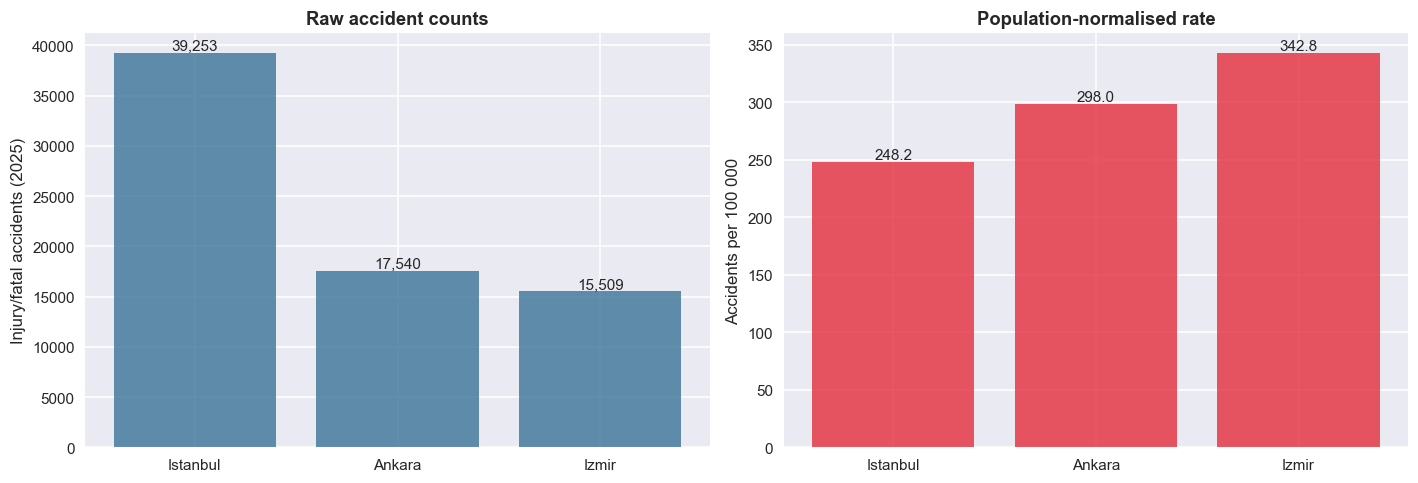

In [15]:
big3 = df[df['province'].isin(['Istanbul', 'Ankara', 'Izmir'])].set_index('province')
big3 = big3.loc[['Istanbul', 'Ankara', 'Izmir']]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(big3.index, big3['injury_fatal_accidents_2025'], color=BLUE, alpha=0.85)
axes[0].set_ylabel('Injury/fatal accidents (2025)')
axes[0].set_title('Raw accident counts', fontweight='bold')
for i, v in enumerate(big3['injury_fatal_accidents_2025']):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

axes[1].bar(big3.index, big3['acc_per_100k'], color=ACCENT, alpha=0.85)
axes[1].set_ylabel('Accidents per 100 000')
axes[1].set_title('Population-normalised rate', fontweight='bold')
for i, v in enumerate(big3['acc_per_100k']):
    axes[1].text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('fig3_big3_cities.png', bbox_inches='tight')
plt.show()


### 3.5 Accident Rate and Alcohol Consumption by IBBS-2 Sub-Region

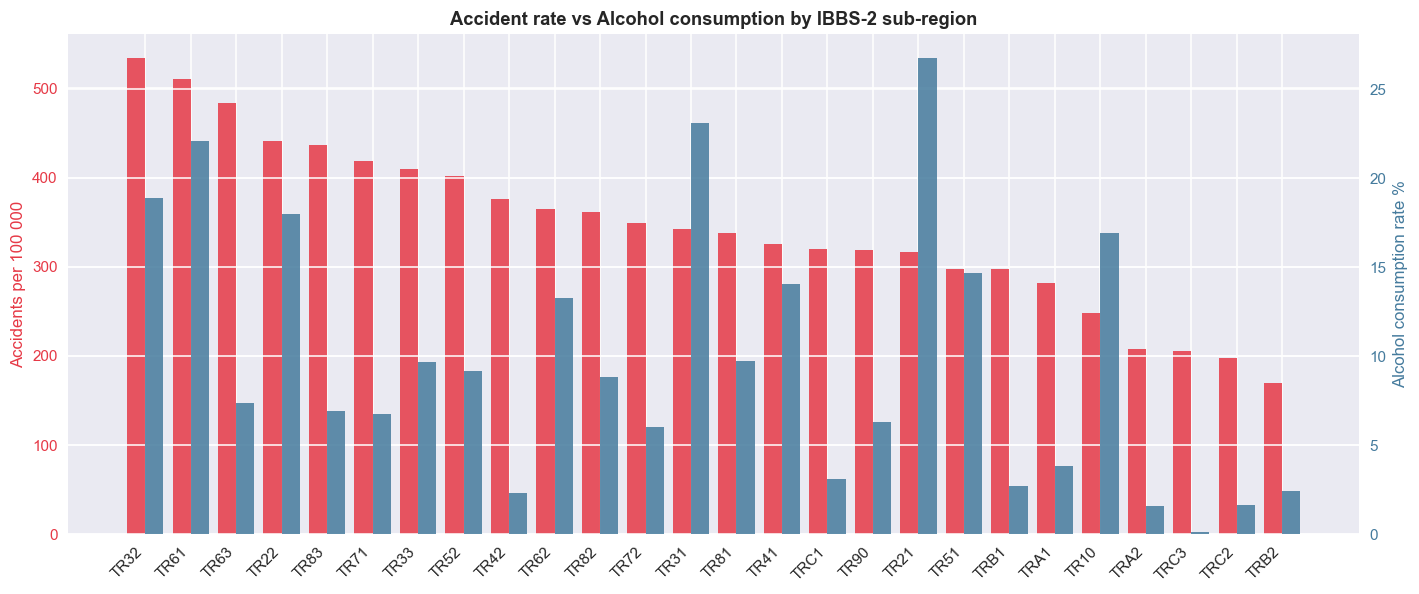

In [16]:
sorted_sr = df_subregion.sort_values('acc_per_100k', ascending=False)

fig, ax1 = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(sorted_sr))
w = 0.4

ax1.bar(x - w/2, sorted_sr['acc_per_100k'], w, color=ACCENT, alpha=0.85,
        label='Acc/100k')
ax1.set_xticks(x)
ax1.set_xticklabels(sorted_sr['nuts2_label'], rotation=45, ha='right')
ax1.set_ylabel('Accidents per 100 000', color=ACCENT)
ax1.tick_params(axis='y', labelcolor=ACCENT)

ax2 = ax1.twinx()
ax2.bar(x + w/2, sorted_sr['alcohol_rate_pct'], w, color=BLUE, alpha=0.85,
        label='Alcohol %')
ax2.set_ylabel('Alcohol consumption rate %', color=BLUE)
ax2.tick_params(axis='y', labelcolor=BLUE)

ax1.set_title('Accident rate vs Alcohol consumption by IBBS-2 sub-region',
              fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_subregional_comparison.png', bbox_inches='tight')
plt.show()


### 3.6 Scatter Plot - Alcohol Rate vs Accident Rate (Sub-Region Level, n=26)

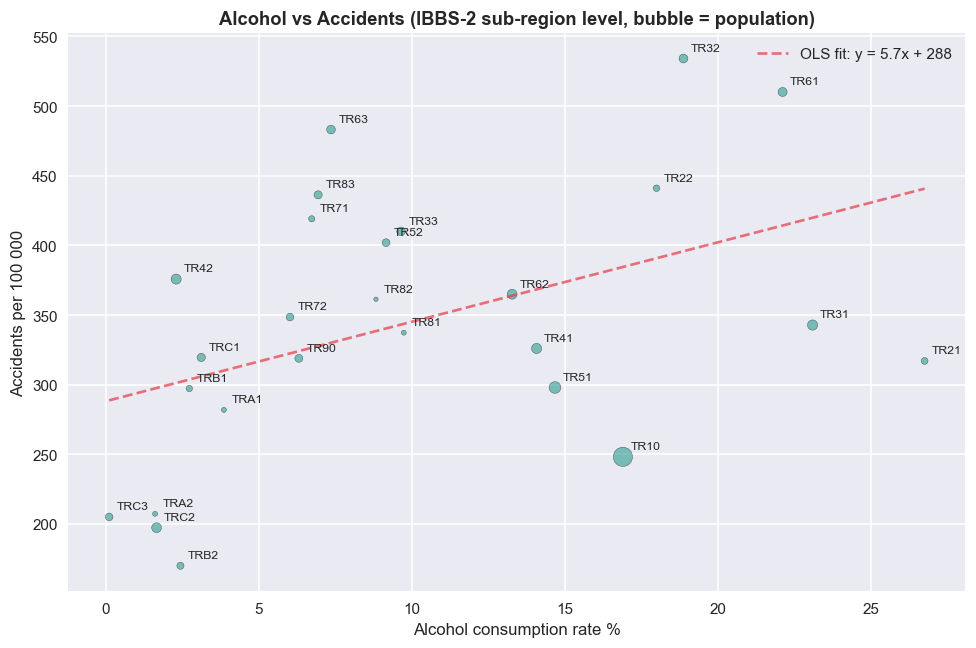

Pearson correlation (sub-region level, n=26): r = +0.448


In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

sizes = df_subregion['total_population'] / 1e5
ax.scatter(df_subregion['alcohol_rate_pct'], df_subregion['acc_per_100k'],
           s=sizes, alpha=0.6, color=GREEN, edgecolor='black')

for _, row in df_subregion.iterrows():
    ax.annotate(row['nuts2_label'],
                (row['alcohol_rate_pct'], row['acc_per_100k']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

m, b = np.polyfit(df_subregion['alcohol_rate_pct'], df_subregion['acc_per_100k'], 1)
xs = np.linspace(df_subregion['alcohol_rate_pct'].min(),
                 df_subregion['alcohol_rate_pct'].max(), 100)
ax.plot(xs, m * xs + b, '--', color=ACCENT, alpha=0.7,
        label=f'OLS fit: y = {m:.1f}x + {b:.0f}')

ax.set_xlabel('Alcohol consumption rate %')
ax.set_ylabel('Accidents per 100 000')
ax.set_title('Alcohol vs Accidents (IBBS-2 sub-region level, bubble = population)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_scatter_alcohol_vs_accidents.png', bbox_inches='tight')
plt.show()

corr = df_subregion[['alcohol_rate_pct', 'acc_per_100k']].corr().iloc[0, 1]
print(f'Pearson correlation (sub-region level, n=26): r = {corr:+.3f}')


### 3.7 Correlation Heatmap - Sub-Regional Variables

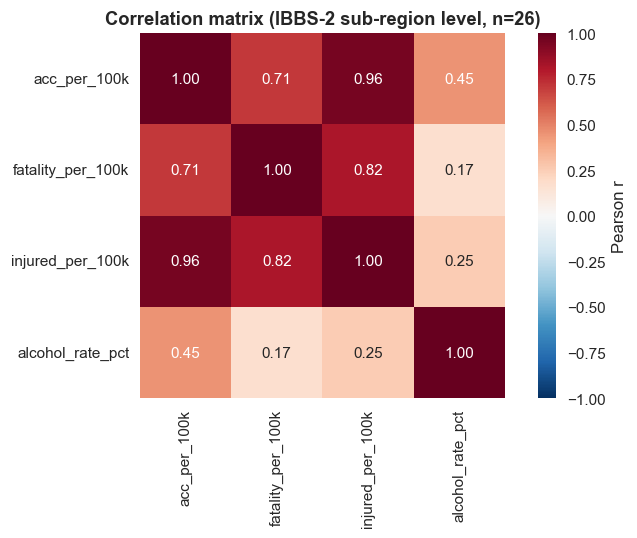

In [18]:
corr_cols = ['acc_per_100k', 'fatality_per_100k', 'injured_per_100k', 'alcohol_rate_pct']
corr_matrix = df_subregion[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix (IBBS-2 sub-region level, n=26)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### 3.8 Year-Over-Year Comparison - 2025 vs Projected 2026

2025 total injury/fatal accidents : 288,253
2026 projected (Q1 * 4)           : 222,328
Projected change                  : -22.9%

  Note: Q1 in Turkey systematically has fewer accidents than later
  quarters (winter, less travel, less tourism). Treat the projection as
  a CONSERVATIVE LOWER BOUND for the year, not a real forecast.


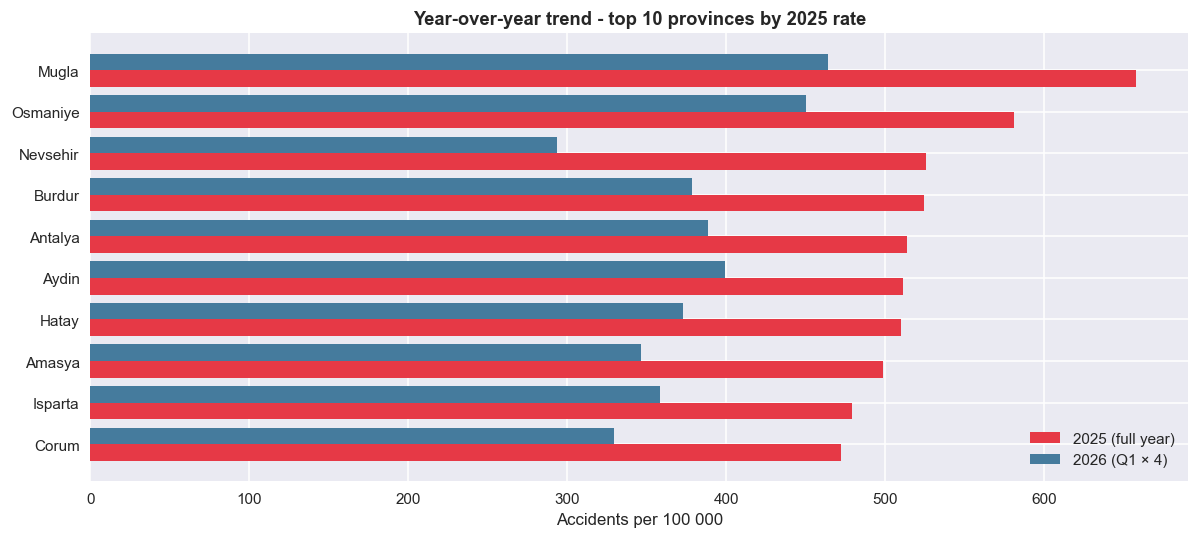

In [19]:
y2025 = df['injury_fatal_accidents_2025'].sum()
y2026 = df['injury_fatal_accidents_2026q1'].sum() * 4
print(f'2025 total injury/fatal accidents : {y2025:,}')
print(f'2026 projected (Q1 * 4)           : {y2026:,}')
print(f'Projected change                  : {(y2026-y2025)/y2025*100:+.1f}%')
print('\n  Note: Q1 in Turkey systematically has fewer accidents than later')
print('  quarters (winter, less travel, less tourism). Treat the projection as')
print('  a CONSERVATIVE LOWER BOUND for the year, not a real forecast.')

top10 = df.nlargest(10, 'acc_per_100k').sort_values('acc_per_100k')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(top10))
w = 0.4

ax.barh(x - w/2, top10['acc_per_100k'],            w, color=ACCENT, label='2025 (full year)')
ax.barh(x + w/2, top10['acc_per_100k_2026q1_proj'], w, color=BLUE,   label='2026 (Q1 × 4)')
ax.set_yticks(x)
ax.set_yticklabels(top10['province'])
ax.set_xlabel('Accidents per 100 000')
ax.set_title('Year-over-year trend - top 10 provinces by 2025 rate', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig7_year_comparison.png', bbox_inches='tight')
plt.show()


## 4. EDA Summary

Key observations from the exploratory data analysis:

- **Population normalisation matters.** Istanbul has by far the most accidents
  in raw counts but ranks below most provinces on accidents per 100 000.
- **Top accident-rate provinces** are dominated by tourism / transit hubs
  (Mugla, Antalya, Osmaniye) and earthquake-affected regions (Hatay).
- **Bottom accident-rate provinces** are mostly in the Northeast and Southeast
  (Hakkari, Mus, Bitlis, Sirnak), the same regions with the lowest alcohol
  consumption.
- **At the sub-region level** (n=26), Pearson correlation between alcohol rate
  and accident rate is positive but moderate (around r ~ +0.3 to +0.5).
- **Year-over-year**, projecting Q1 2026 to a full year gives lower accident
  counts than 2025, but this is mostly seasonal (Q1 has fewer accidents than
  Q2/Q3) and not a real downward trend.

The formal hypothesis tests for these patterns are in
`DSA210_Hypothesis_Testing.ipynb`.
